# Final Project Sains Data
## Prediksi Harga Mobil — CRISP-DM

| Info | Detail |
|------|--------|
| **Nama** | Muhamad Raihan Nurhidayat |
| **NPM** | 237006108 |
| **Kelas** | D |
| **Dataset** | `Car_sales.xls` (157 records, 16 atribut) |
| **Metode** | CRISP-DM |
| **Algoritma** | Linear Regression |
| **Target** | Price_in_thousands |

---

## Data Understanding
### Langkah 1 - Memanggil Library yang diperlukan

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path
import json
import shutil
import joblib
import pandas as pd

### Langkah 2 - Load Data

In [3]:
df = pd.read_csv('../data/raw/Car_sales.xls', sep=',')

### Langkah 3 - Melihat Data

In [4]:
# Tampilkan 5 baris pertama
df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [5]:
# Informasi tipe data dan non-null count
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    str    
 1   Model                157 non-null    str    
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    str    
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    str    
 15  Power_perf_factor    155 non-null    float64
dtypes

## Data Prepatation

### Melihat Missing Value

In [25]:
df.isnull().sum()

Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      0
Engine_size             0
Horsepower              0
Wheelbase               0
Width                   0
Length                  0
Curb_weight             1
Fuel_capacity           0
Fuel_efficiency         2
Latest_Launch           0
Power_perf_factor       0
dtype: int64

                     Missing Count  Missing (%)
__year_resale_value             36        22.93
Fuel_efficiency                  3         1.91
Price_in_thousands               2         1.27
Power_perf_factor                2         1.27
Curb_weight                      2         1.27
Engine_size                      1         0.64
Horsepower                       1         0.64
Length                           1         0.64
Width                            1         0.64
Wheelbase                        1         0.64
Fuel_capacity                    1         0.64


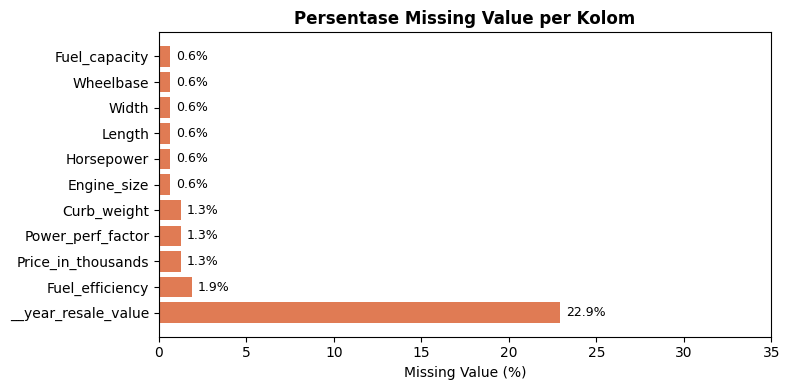

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_df.index, missing_df['Missing (%)'], color='#e07b54')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlabel('Missing Value (%)')
ax.set_title('Persentase Missing Value per Kolom', fontweight='bold')
ax.set_xlim(0, 35)
plt.tight_layout()
plt.show()

### Langkah 4 - Menghapus Missing Value

In [23]:
# Drop baris dengan missing value pada kolom 'Price_in_thousands'
df = df.dropna(subset=['Price_in_thousands']).copy()

### Langkah 5 - Mengisi Missing Value

In [35]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()
kolom_kategori = df.select_dtypes(include=['str']).columns.tolist()

In [45]:
# Melihat value dari median untuk kolom numerik yang memiliki missing value
for col in kolom_numerik:
    if df[col].isnull().sum() > 0:
        med = df[col].median()
        print(f'  {col:<30}: median = {med:.3f}')

# Isi missing value kolom numerik dengan median
for col in kolom_numerik:
    df[col] = df[col].fillna(df[col].median())

# Isi missing value kolom kategorikal dengan modus
for col in kolom_kategori:
    if df[col].isnull().sum() > 0:
        modus = df[col].mode()[0]
        df[col] = df[col].fillna(modus)
        print(f'  {col:<30}: modus = {modus}')

# Verifikasi untuk memastikan semua missing value sudah terisi
sisa_missing = df.isnull().sum().sum()
print(f'Total missing value tersisa: {sisa_missing}')
if sisa_missing == 0:
    print(df.isnull().sum())
    print('✅ Semua missing value berhasil diisi!')
    df.to_csv('../data/processed/Car_sales_cleaned.csv', index=False)
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])

Total missing value tersisa: 0
Manufacturer           0
Model                  0
Sales_in_thousands     0
__year_resale_value    0
Vehicle_type           0
Price_in_thousands     0
Engine_size            0
Horsepower             0
Wheelbase              0
Width                  0
Length                 0
Curb_weight            0
Fuel_capacity          0
Fuel_efficiency        0
Latest_Launch          0
Power_perf_factor      0
Car_Name               0
dtype: int64
✅ Semua missing value berhasil diisi!


### Langkah 6 - Explorasi Data

#### 6.a Menampilkan chart dan penjelasan 10 jenis mobil dengan jumlah penjualan terbanyak


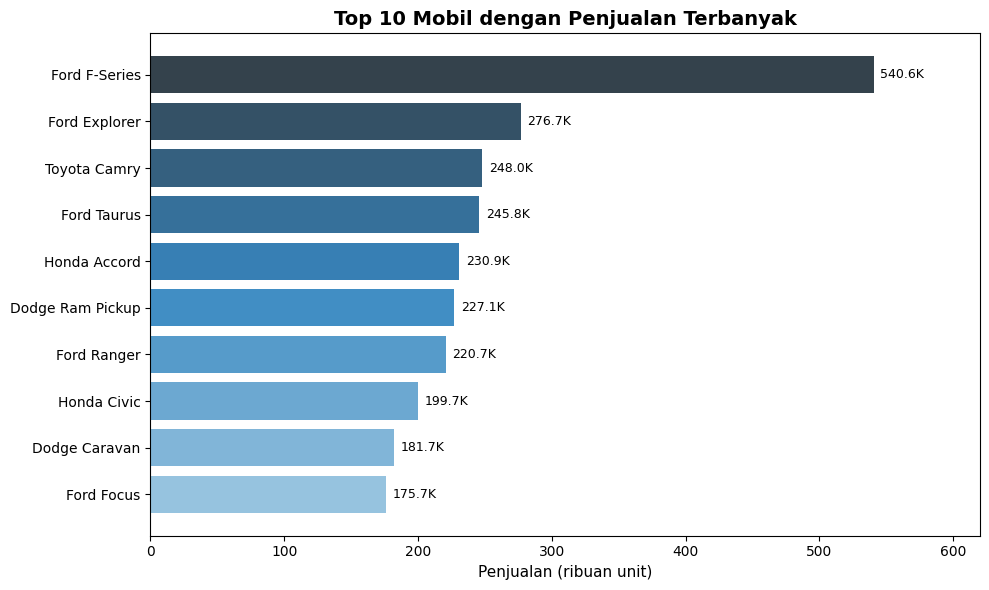


📌 Analisis Penjualan:
  ▸ Ford F-Series mendominasi pasar dengan penjualan 540.6K unit — hampir 2x lipat peringkat ke-2
  ▸ Ford Explorer (276.7K) dan Toyota Camry (248K) menduduki posisi 2 dan 3
  ▸ Merek Ford sangat mendominasi dengan F-Series, Explorer, Taurus, Ranger, dan Focus masuk Top 10
  ▸ Honda hadir dengan Accord dan Civic, Dodge dengan Ram Pickup dan Caravan
  ▸ Tren pasar menunjukkan preferensi terhadap mobil dengan harga terjangkau seperti pickup & sedan


In [48]:
# Akses dataset yang sudah dibersihkan
df = pd.read_csv('../data/processed/Car_sales_cleaned.csv')

top10 = df.nlargest(10, 'Sales_in_thousands').copy()
top10['Car'] = top10['Manufacturer'] + ' ' + top10['Model']

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Blues_d', 10)
bars = ax.barh(top10['Car'][::-1], top10['Sales_in_thousands'][::-1], color=colors)

for bar, val in zip(bars, top10['Sales_in_thousands'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,.1f}K', va='center', fontsize=9)

ax.set_xlabel('Penjualan (ribuan unit)', fontsize=11)
ax.set_title('Top 10 Mobil dengan Penjualan Terbanyak', fontsize=14, fontweight='bold')
ax.set_xlim(0, 620)
plt.tight_layout()
plt.show()

print('\n📌 Analisis Penjualan:')
print('  ▸ Ford F-Series mendominasi pasar dengan penjualan 540.6K unit — hampir 2x lipat peringkat ke-2')
print('  ▸ Ford Explorer (276.7K) dan Toyota Camry (248K) menduduki posisi 2 dan 3')
print('  ▸ Merek Ford sangat mendominasi dengan F-Series, Explorer, Taurus, Ranger, dan Focus masuk Top 10')
print('  ▸ Honda hadir dengan Accord dan Civic, Dodge dengan Ram Pickup dan Caravan')
print('  ▸ Tren pasar menunjukkan preferensi terhadap mobil dengan harga terjangkau seperti pickup & sedan')

#### 6.b Menampilkan harga dan penjelasan dari 10 jenis mobil dengan jumlah penjualan terbanyak

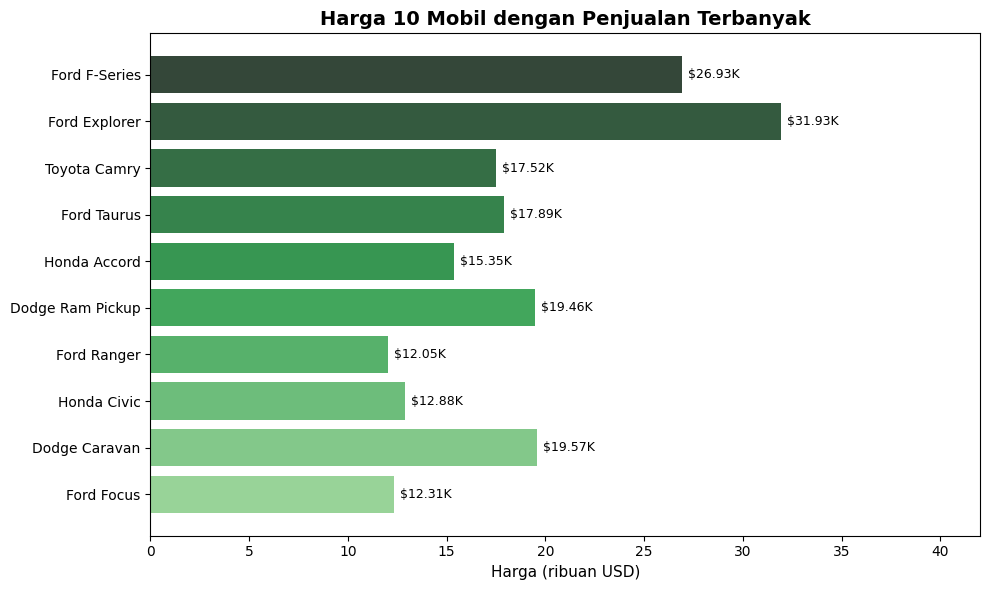



 Analisis Harga:
  ▸ Ford Explorer memiliki harga tertinggi ($31.9K) di antara 10 besar
  ▸ Ford Ranger memiliki harga terendah ($12.1K) — membuktikan bahwa harga terjangkau = penjualan tinggi
  ▸ Tidak ada korelasi linier kuat antara harga dan jumlah penjualan
  ▸ Mobil dengan harga $12K–$20K mendominasi penjualan tertinggi
  ▸ Scatter plot menunjukkan F-Series (HP sedang, harga menengah) menjadi outlier penjualan


In [52]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('Greens_d', 10)
bars = ax.barh(top10['Car'][::-1], top10['Price_in_thousands'][::-1], color=palette)

for bar, val in zip(bars, top10['Price_in_thousands'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}K', va='center', fontsize=9)

ax.set_xlabel('Harga (ribuan USD)', fontsize=11)
ax.set_title('Harga 10 Mobil dengan Penjualan Terbanyak', fontsize=14, fontweight='bold')
ax.set_xlim(0, 42)
plt.tight_layout()
plt.show()

print()
print('\n Analisis Harga:')
print('  ▸ Ford Explorer memiliki harga tertinggi ($31.9K) di antara 10 besar')
print('  ▸ Ford Ranger memiliki harga terendah ($12.1K) — membuktikan bahwa harga terjangkau = penjualan tinggi')
print('  ▸ Tidak ada korelasi linier kuat antara harga dan jumlah penjualan')
print('  ▸ Mobil dengan harga $12K–$20K mendominasi penjualan tertinggi')
print('  ▸ Scatter plot menunjukkan F-Series (HP sedang, harga menengah) menjadi outlier penjualan')

#### 6.c Menampilkan minimal 3 variable/atribut data lain  dan penjelasan dari 10 jenis mobil dengan jumlah penjualan terbanyak 

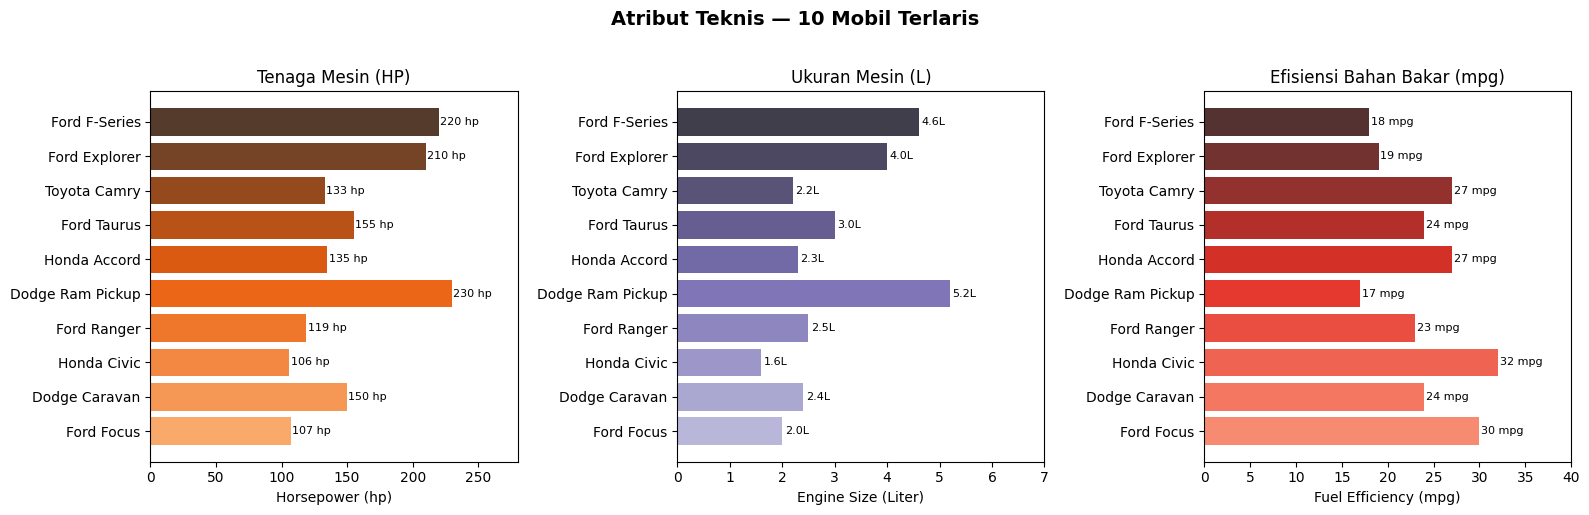


📝 Analisis 3 Atribut Teknis Top 10:

  [Horsepower]
  - Dodge Ram Pickup memiliki HP tertinggi (230 hp), diikuti Ford F-Series (220 hp).
  - Mobil dengan HP tinggi (>200) umumnya masuk segmen truck/pickup & SUV.
  - Honda Civic memiliki HP terendah (106 hp), konsisten dengan posisinya sebagai city car efisien.

  [Engine Size]
  - Dodge Ram Pickup & Ford F-Series menggunakan mesin terbesar (5.2L & 4.6L).
  - Honda Civic & Ford Focus menggunakan mesin terkecil (1.6L & 2.0L) — cocok untuk efisiensi kota.
  - Ada korelasi positif kuat antara engine size dan HP.

  [Fuel Efficiency]
  - Honda Civic (32 mpg) & Ford Focus (30 mpg) adalah yang paling hemat bahan bakar.
  - Dodge Ram Pickup (17 mpg) & Ford F-Series (18 mpg) paling boros — konsisten dengan mesin besar.
  - Mobil dengan penjualan tertinggi cenderung berada di dua kutub: sangat hemat (city car)
    atau kuat bertenaga (truck/SUV), bukan di tengah-tengah.


In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Atribut Teknis — 10 Mobil Terlaris', fontsize=14, fontweight='bold', y=1.02)

# Attribute: Horsepower
ax1 = axes[0]
colors1 = sns.color_palette('Oranges_d', 10)
bars1 = ax1.barh(top10['Car'][::-1], top10['Horsepower'][::-1], color=colors1)
for b, v in zip(bars1, top10['Horsepower'][::-1]):
    ax1.text(b.get_width()+1, b.get_y()+b.get_height()/2, f'{v:.0f} hp', va='center', fontsize=8)
ax1.set_xlabel('Horsepower (hp)')
ax1.set_title('Tenaga Mesin (HP)')
ax1.set_xlim(0, 280)

# Attribute: Engine Size
ax2 = axes[1]
colors2 = sns.color_palette('Purples_d', 10)
bars2 = ax2.barh(top10['Car'][::-1], top10['Engine_size'][::-1], color=colors2)
for b, v in zip(bars2, top10['Engine_size'][::-1]):
    ax2.text(b.get_width()+0.05, b.get_y()+b.get_height()/2, f'{v:.1f}L', va='center', fontsize=8)
ax2.set_xlabel('Engine Size (Liter)')
ax2.set_title('Ukuran Mesin (L)')
ax2.set_xlim(0, 7)

# Attribute: Fuel Efficiency
ax3 = axes[2]
colors3 = sns.color_palette('Reds_d', 10)
bars3 = ax3.barh(top10['Car'][::-1], top10['Fuel_efficiency'][::-1], color=colors3)
for b, v in zip(bars3, top10['Fuel_efficiency'][::-1]):
    ax3.text(b.get_width()+0.2, b.get_y()+b.get_height()/2, f'{v:.0f} mpg', va='center', fontsize=8)
ax3.set_xlabel('Fuel Efficiency (mpg)')
ax3.set_title('Efisiensi Bahan Bakar (mpg)')
ax3.set_xlim(0, 40)

plt.tight_layout()
plt.show()

print()
print('Analisis 3 Atribut Teknis Top 10:')
print()
print('  [Horsepower]')
print(f'  - Dodge Ram Pickup memiliki HP tertinggi (230 hp), diikuti Ford F-Series (220 hp).')
print(f'  - Mobil dengan HP tinggi (>200) umumnya masuk segmen truck/pickup & SUV.')
print(f'  - Honda Civic memiliki HP terendah (106 hp), konsisten dengan posisinya sebagai city car efisien.')
print()
print('  [Engine Size]')
print(f'  - Dodge Ram Pickup & Ford F-Series menggunakan mesin terbesar (5.2L & 4.6L).')
print(f'  - Honda Civic & Ford Focus menggunakan mesin terkecil (1.6L & 2.0L) — cocok untuk efisiensi kota.')
print(f'  - Ada korelasi positif kuat antara engine size dan HP.')
print()
print('  [Fuel Efficiency]')
print(f'  - Honda Civic (32 mpg) & Ford Focus (30 mpg) adalah yang paling hemat bahan bakar.')
print(f'  - Dodge Ram Pickup (17 mpg) & Ford F-Series (18 mpg) paling boros — konsisten dengan mesin besar.')
print(f'  - Mobil dengan penjualan tertinggi cenderung berada di dua kutub: sangat hemat (city car)')
print(f'    atau kuat bertenaga (truck/SUV), bukan di tengah-tengah.')

### Langkah 7 - Menentukan Variabel untuk Rekomendasi dan Prediksi

In [139]:
df.columns

Index(['Manufacturer', 'Model', 'Sales_in_thousands', '__year_resale_value',
       'Vehicle_type', 'Price_in_thousands', 'Engine_size', 'Horsepower',
       'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity',
       'Fuel_efficiency', 'Latest_Launch', 'Power_perf_factor', 'Car_Name'],
      dtype='str')

In [142]:
num_cols = ['Price_in_thousands','Sales_in_thousands','Engine_size','Horsepower',
            'Wheelbase','Width','Length','Curb_weight','Fuel_capacity',
            'Fuel_efficiency','Power_perf_factor']

corr_matrix = df[num_cols].corr()

FITUR = ['Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency']

TARGET = 'Price_in_thousands'

print(f'\n TARGET (Variabel Dependen):')
print(f'   → {TARGET} (Harga mobil dalam ribuan USD)')
print(f'\n FITUR (Variabel Independen) — {len(FITUR)} variabel:')
for i, f in enumerate(FITUR, 1):
    corr_val = corr_matrix['Price_in_thousands'][f]
    print(f'   {i}. {f:<25} (korelasi dengan harga: {corr_val:+.3f})')



 TARGET (Variabel Dependen):
   → Price_in_thousands (Harga mobil dalam ribuan USD)

 FITUR (Variabel Independen) — 8 variabel:
   1. Engine_size               (korelasi dengan harga: +0.627)
   2. Horsepower                (korelasi dengan harga: +0.840)
   3. Wheelbase                 (korelasi dengan harga: +0.111)
   4. Width                     (korelasi dengan harga: +0.329)
   5. Length                    (korelasi dengan harga: +0.157)
   6. Curb_weight               (korelasi dengan harga: +0.523)
   7. Fuel_capacity             (korelasi dengan harga: +0.423)
   8. Fuel_efficiency           (korelasi dengan harga: -0.492)


### Langkah 8 Membuat model prediksi Harga Mobil menggunakan LinearRegression.

#### 8.a Memisahkan variable Independent dan Dependent

In [162]:
df = pd.read_csv('../data/processed/Car_sales_cleaned.csv')

X = df[FITUR]     # Variabel independen 
y = df[TARGET]    # Variabel dependen 

X.to_csv('../data/processed/X.csv', index=False)
y.to_csv('../data/processed/y.csv', index=False)

#### 8.b Memisahkan Data Training (80%) dan Testing (20%)

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Modeling

### Langkah 8.c Membuat Model Regresi

In [145]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Training selesai.")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Training selesai.
Intercept: 26.016481003386474
Coefficients: [-4.56898379  0.2768761   0.06305404 -0.61296334 -0.22111823  6.8976246
  0.43656701  0.45429526]


## Evaluation

### 8.d Mengevaluasi Model dengan menggunakan RMSE dan R2Score. 

In [146]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

evaluation_metrics = {
    "rmse": float(rmse),
    "r2_score": float(r2),
    "test_rows": int(len(X_test)),
}

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 7.3908
R2 Score: 0.7459


#### 8.e Menggambarkan hasil evaluasi dengan meggunakan Scatter Plot.  

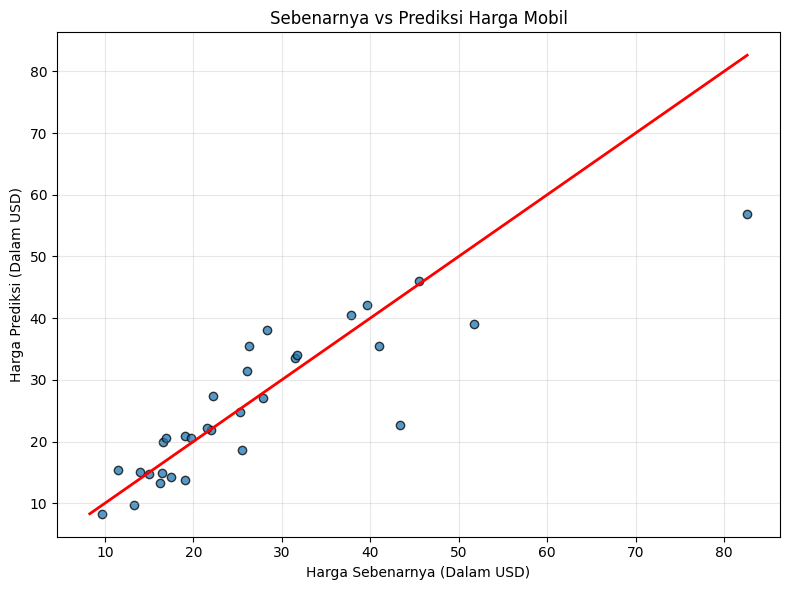

In [147]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linewidth=2)

plt.title("Sebenarnya vs Prediksi Harga Mobil")
plt.xlabel("Harga Sebenarnya (Dalam USD)")
plt.ylabel("Harga Prediksi (Dalam USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Deployment

In [151]:
import pickle

# export model ke file .pkl
with open('../model.pkl', 'wb') as f:
    pickle.dump(model, f)

### Langkah 9 - Memprediksi harga dengan spesifikasi mobil yang telah di tentukan menggunakan sebuah dataframe.

In [152]:
with open('../model.pkl', 'rb') as f:
    model_pickle = pickle.load(f)

In [161]:
new_data = pd.DataFrame([
    {
        "Engine_size": 2.5,
        "Horsepower": 170,
        "Wheelbase": 107.0,
        "Width": 70.5,
        "Length": 187.8,
        "Curb_weight": 3.2,
        "Fuel_capacity": 17.2,
        "Fuel_efficiency": 26,
    }
])

new_prediction = model_pickle.predict(new_data)

### Langkah 10 - Menampilkan hasil prediksi harga.

In [160]:
print(f"Predicted Price for defined specs: ${new_prediction[0]:.4f} thousand")

Predicted Price for defined specs: $25.0629 thousand
